
<h1 align="center"><B> <FONT COLOR="#76b4e9">Student Survey: Simple Linear Regression using Scikit Learn, OLS, and Parameter Saving 
 - Machine Learning - Lab 3</FONT></B></h1>

<B><h3 align="center">Data Preprocessing, Visualisation & Exploratory Data Analysis</h3>

<h3 align="center">Students Report</B></h3>



<h3 align=""><FONT COLOR="#76b4e9">Part A: Data Collection and Preprocessing </FONT></B></h3>
<B><h3 align="">Tasks to Perform</h3>

<B><h3 align="">Load CSV</h3>

In [3]:
import pandas as pd

student_data = pd.read_csv("student_survey.csv")


In [4]:
student_data.head()

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 2 — Rename Long Columns</FONT></B></h1>
<B><h3 align="center">Use Shorter Name</h3>


In [5]:
student_data = student_data.rename(columns={
    'Your CIA % of last semester': 'CIA',
    'Your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance',
    'Job role that you are interested in': 'Role'
})

<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 3 — Keep Only Needed Columns</FONT></B></h1>


In [6]:
student_data = student_data[['CIA', 'Attendance', 'GPA', 'Role']]
student_data.head()

,CIA,Attendance,GPA,Role
0,69,98,3.40,Software Development Engineer (SDE)
1,75,95,3.69,Software Development Engineer (SDE)
2,82,95,3.41,Full Stack Developer
3,91,92,3.60,Full Stack Developer
4,70,93,3.54,Software Development Engineer (SDE)


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 4 — Checking Missing Values</FONT></B></h1>


In [7]:
print(student_data.isnull().sum())

CIA           0
Attendance    0
GPA           0
Role          0
dtype: int64


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 5 — Remove % Symbols</FONT></B></h1>


In [8]:
student_data['CIA'] = student_data['CIA'].astype(str).str.replace('%', '', regex=False)
student_data['Attendance'] = student_data['Attendance'].astype(str).str.replace('%', '', regex=False)


<h3 align="center">After Removing</B></h3>


In [9]:
student_data.head()


,CIA,Attendance,GPA,Role
0,69,98,3.40,Software Development Engineer (SDE)
1,75,95,3.69,Software Development Engineer (SDE)
2,82,95,3.41,Full Stack Developer
3,91,92,3.60,Full Stack Developer
4,70,93,3.54,Software Development Engineer (SDE)


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 6 — Convert to Numeric</FONT></B></h1>


In [10]:
student_data['CIA'] = pd.to_numeric(student_data['CIA'], errors='coerce')
student_data['Attendance'] = pd.to_numeric(student_data['Attendance'], errors='coerce')
student_data['GPA'] = pd.to_numeric(student_data['GPA'], errors='coerce')


<h3 align="center">Checking</B></h3>


In [11]:
student_data.dtypes 

CIA           float64
Attendance    float64
GPA           float64
Role           object
dtype: object

In [12]:
student_data

,CIA,Attendance,GPA,Role
0,69.00,98.00,3.40,Software Development Engineer (SDE)
1,75.00,95.00,3.69,Software Development Engineer (SDE)
2,82.00,95.00,3.41,Full Stack Developer
3,91.00,92.00,3.60,Full Stack Developer
4,70.00,93.00,3.54,Software Development Engineer (SDE)
5,75.00,98.00,3.67,Machine Learning Engineer
6,74.00,94.00,3.40,Full Stack Developer
7,68.00,85.00,3.40,Cyber Security Analyst
8,73.00,90.00,3.60,Software Development Engineer (SDE)
9,79.00,93.00,3.73,Software Development Engineer (SDE)


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 7 — Remove Duplicates</FONT></B></h1>


In [13]:
print("Duplicates:", student_data.duplicated().sum())

Duplicates: 0


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 8 — Apply Logical Constraints</FONT></B></h1>



<h3 align="">Before Cleaning</B></h3>


In [14]:
print("Before cleaning:", student_data.shape)

Before cleaning: (50, 4)



<h3 align="">CIA Range</B></h3>


In [15]:
student_data = student_data[(student_data['CIA'] >= 0) & (student_data['CIA'] <= 100)]



<h3 align="">Attendance Range</B></h3>

In [16]:
student_data = student_data[(student_data['Attendance'] >= 0) & (student_data['Attendance'] <= 100)]


<h3 align="">GPA Range</B></h3>

In [17]:
student_data = student_data[(student_data['GPA'] >= 0) & (student_data['GPA'] <= 10)]


<h3 align="">After Cleaning</B></h3>


In [18]:
print("After cleaning:", student_data.shape)

After cleaning: (50, 4)


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 9 — Outlier Check</FONT></B></h1>



<h3 align="">Cia Outlier</B></h3>

In [19]:
Q1 = student_data['CIA'].quantile(0.25)
Q3 = student_data['CIA'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

cia_outliers = student_data[(student_data['CIA'] < lower) | (student_data['CIA'] > upper)]

print("CIA Outliers:")
print(cia_outliers)

CIA Outliers:
     CIA  Attendance  GPA                                 Role
3   91.0        92.0  3.6                 Full Stack Developer
13   7.0        85.0  8.0  Software Development Engineer (SDE)



<h3 align="">Attendance Outlier</B></h3>

In [20]:
Q1 = student_data['Attendance'].quantile(0.25)
Q3 = student_data['Attendance'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

attendance_outliers = student_data[(student_data['Attendance'] < lower) | (student_data['Attendance'] > upper)]

print("Attendance Outliers:")
print(attendance_outliers)

Attendance Outliers:
     CIA  Attendance  GPA                                 Role
7   68.0        85.0  3.4               Cyber Security Analyst
13   7.0        85.0  8.0  Software Development Engineer (SDE)
15  60.0        85.0  3.0                       Data Scientist



<h3 align="">GPA Outlier</B></h3>

In [21]:
Q1 = student_data['GPA'].quantile(0.25)
Q3 = student_data['GPA'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

gpa_outliers = student_data[(student_data['GPA'] < lower) | (student_data['GPA'] > upper)]

print("GPA Outliers:")
print(gpa_outliers)

GPA Outliers:
     CIA  Attendance   GPA                                 Role
13   7.0        85.0  8.00  Software Development Engineer (SDE)
48  66.0        90.0  2.74                 Full Stack Developer


<h1 align="center"><B> <FONT COLOR="#76b4e9">Step 10 — Treating Outlier </FONT></B></h1>



<h3 align="">CIA Typo</B></h3>


In [22]:
student_data.loc[student_data['CIA'] == 7, 'CIA'] = 70

In [23]:
student_data

,CIA,Attendance,GPA,Role
0,69.00,98.00,3.40,Software Development Engineer (SDE)
1,75.00,95.00,3.69,Software Development Engineer (SDE)
2,82.00,95.00,3.41,Full Stack Developer
3,91.00,92.00,3.60,Full Stack Developer
4,70.00,93.00,3.54,Software Development Engineer (SDE)
5,75.00,98.00,3.67,Machine Learning Engineer
6,74.00,94.00,3.40,Full Stack Developer
7,68.00,85.00,3.40,Cyber Security Analyst
8,73.00,90.00,3.60,Software Development Engineer (SDE)
9,79.00,93.00,3.73,Software Development Engineer (SDE)



<h3 align="">GPA > 4</B></h3>


In [24]:
student_data[student_data['GPA'] > 4]

,CIA,Attendance,GPA,Role
13,70.0,85.0,8.0,Software Development Engineer (SDE)


In [25]:
student_data.loc[
    (student_data['GPA'] > 4) & (student_data['GPA'] <= 10),
    'GPA'
] = (
    student_data.loc[
        (student_data['GPA'] > 4) & (student_data['GPA'] <= 10),
        'GPA'
    ] / 10
) * 4

In [26]:
student_data[student_data['GPA'] > 4]

,CIA,Attendance,GPA,Role


<h1 align="center"><B> <FONT COLOR="#76b4e9">Final Data After Cleaning </FONT></B></h1>


In [27]:
student_data

,CIA,Attendance,GPA,Role
0,69.00,98.00,3.40,Software Development Engineer (SDE)
1,75.00,95.00,3.69,Software Development Engineer (SDE)
2,82.00,95.00,3.41,Full Stack Developer
3,91.00,92.00,3.60,Full Stack Developer
4,70.00,93.00,3.54,Software Development Engineer (SDE)
5,75.00,98.00,3.67,Machine Learning Engineer
6,74.00,94.00,3.40,Full Stack Developer
7,68.00,85.00,3.40,Cyber Security Analyst
8,73.00,90.00,3.60,Software Development Engineer (SDE)
9,79.00,93.00,3.73,Software Development Engineer (SDE)


<h1 align="center"><B> <FONT COLOR="#76b4e9">Distribution of numeric data </FONT></B></h1>


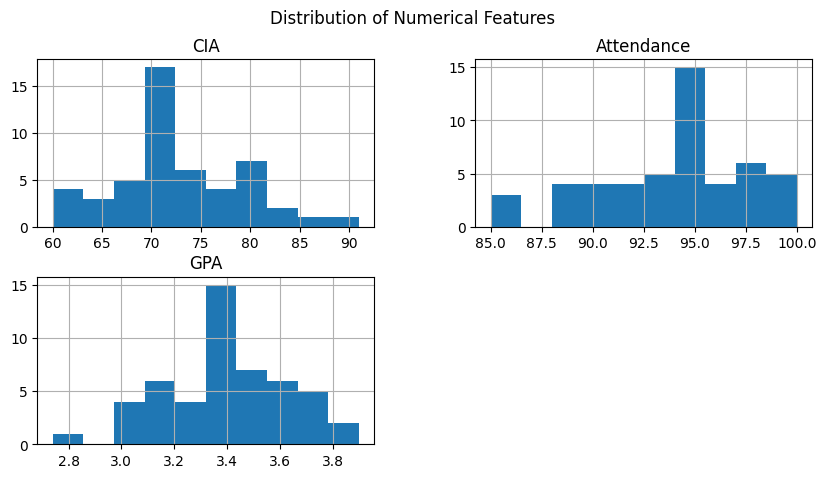

In [28]:
import matplotlib.pyplot as plt

student_data[['CIA', 'Attendance', 'GPA']].hist(figsize=(10,5), bins=10)
plt.suptitle("Distribution of Numerical Features")
plt.show()

<h1 align="center"><B> <FONT COLOR="#76b4e9">Box Plot for outliers </FONT></B></h1>


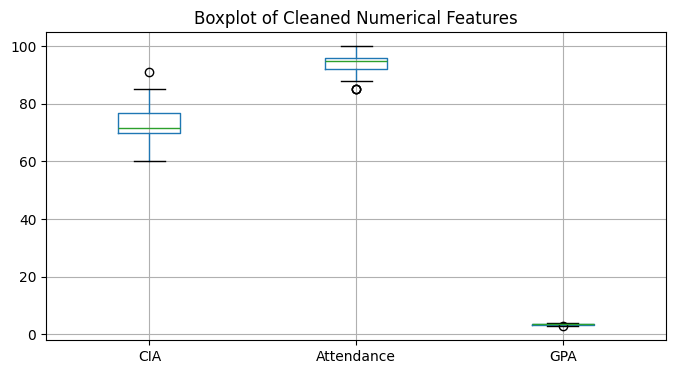

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
student_data[['CIA', 'Attendance', 'GPA']].boxplot()
plt.title("Boxplot of Cleaned Numerical Features")
plt.show()

<h1 align="center"><B> <FONT COLOR="#76b4e9">CIA vs GPA</FONT></B></h1>


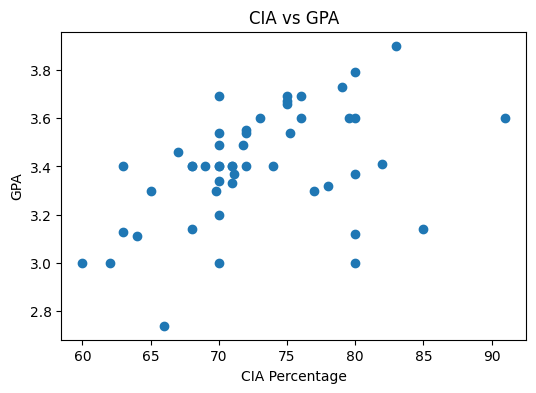

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(student_data['CIA'], student_data['GPA'])
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA vs GPA")
plt.show()

<h1 align="center"><B> <FONT COLOR="#76b4e9">Attendance vs GPA</FONT></B></h1>


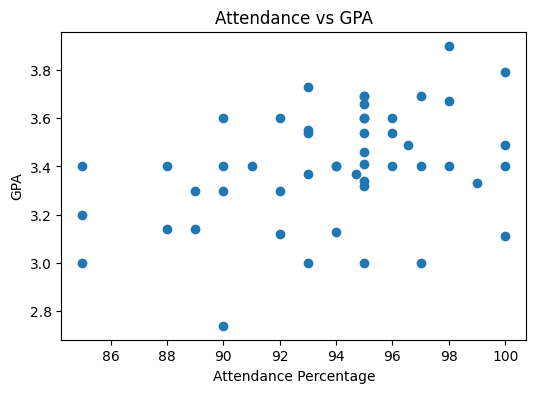

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(student_data['Attendance'], student_data['GPA'])
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Attendance vs GPA")
plt.show()

<h1 align="center"><B> <FONT COLOR="#76b4e9">Correlation to see how strong the variables are related</FONT></B></h1>


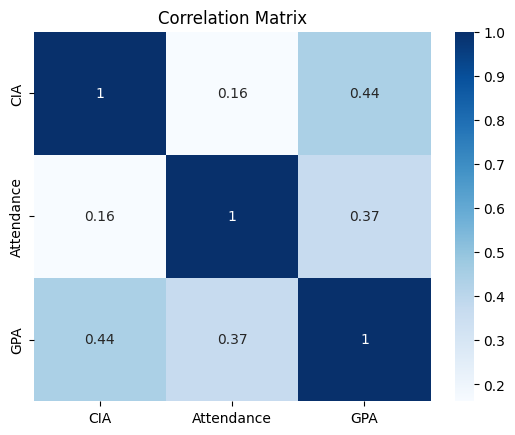

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = student_data[['CIA', 'Attendance', 'GPA']].corr()

sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()

<h1 align="center"><B> <FONT COLOR="#76b4e9">Part 2 Regression Experiments</FONT></B></h1>



<h3 align="">Experiment 1</B></h3>

<h3 align="">CIA and GPA</B></h3>



In [33]:
X1 = student_data[['CIA']]
y1 = student_data['GPA']

In [34]:
print(X1.shape)
print(y1.shape)

(50, 1)
(50,)


Slope: 0.012783144582063033
Intercept: 2.4655814552535955

Actual vs Predicted:
   Actual GPA  Predicted GPA
0        3.20       3.360402
1        3.30       3.296486
2        3.79       3.488233
3        3.66       3.424317
4        3.40       3.373185
5        2.74       3.309269
6        3.40       3.360402
7        3.55       3.385968
8        3.60       3.488233
9        3.49       3.383156

Regression Equation: GPA = 0.0128(CIA) + 2.4656


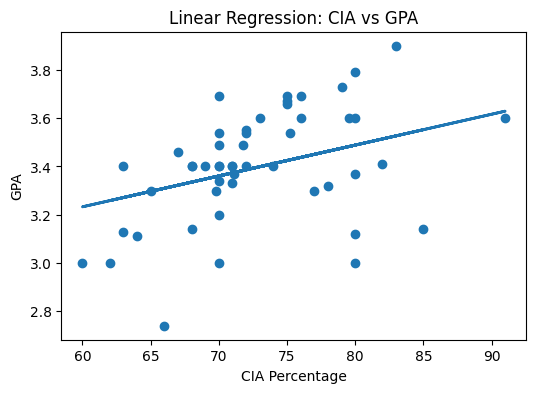

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Train model
cia_model = LinearRegression()
cia_model.fit(X1_train, y1_train)

# Model parameters
CIA_slope = cia_model.coef_[0]
CIA_intercept = cia_model.intercept_

print("Slope:", CIA_slope)
print("Intercept:", CIA_intercept)

# Predictions
cia_y_pred = cia_model.predict(X1_test)

# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual GPA': y1_test.values,
    'Predicted GPA': cia_y_pred
})

print("\nActual vs Predicted:")
print(comparison)

# Regression equation
print(f"\nRegression Equation: GPA = {CIA_slope:.4f}(CIA) + {CIA_intercept:.4f}")

# Visualization
plt.figure(figsize=(6,4))
plt.scatter(X1, y1)
plt.plot(X1, cia_model.predict(X1), linewidth=2)
plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("Linear Regression: CIA vs GPA")
plt.show()

In [36]:
print("\nActual vs Predicted:")
print(comparison)


Actual vs Predicted:
   Actual GPA  Predicted GPA
0        3.20       3.360402
1        3.30       3.296486
2        3.79       3.488233
3        3.66       3.424317
4        3.40       3.373185
5        2.74       3.309269
6        3.40       3.360402
7        3.55       3.385968
8        3.60       3.488233
9        3.49       3.383156


In [37]:
print("Slope:", CIA_slope)
print("Intercept:", CIA_intercept)

Slope: 0.012783144582063033
Intercept: 2.4655814552535955


In [58]:
cia_y_pred = cia_model.predict(X1_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y1_test, cia_y_pred)
mse = mean_squared_error(y1_test, cia_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y1_test, cia_y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R² =", r2)

MAE = 0.17196916429401782
MSE = 0.05495190758040398
RMSE = 0.2344182321842821
R² = 0.2902196099197376



<h3 align="">Experiment 2</B></h3>

<h3 align="">Attendance and GPA</B></h3>



Slope: 0.015844580750996744
Intercept: 1.908332129243164

Actual vs Predicted:
   Actual GPA  Predicted GPA
0        3.20       3.255121
1        3.30       3.318500
2        3.79       3.492790
3        3.66       3.413567
4        3.40       3.350189
5        2.74       3.334344
6        3.40       3.429412
7        3.55       3.381878
8        3.60       3.413567
9        3.49       3.437968

Regression Equation: GPA = 0.0158(Attendance) + 1.9083


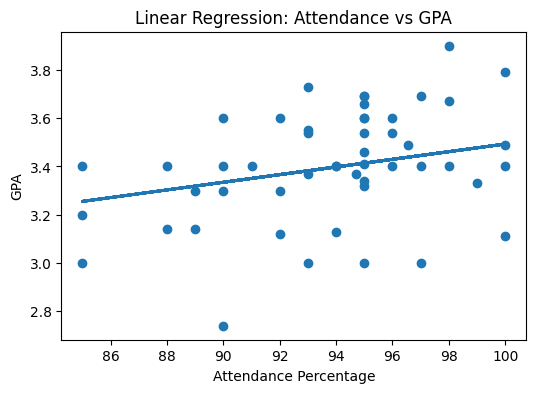

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Independent and dependent variables
X = student_data[['Attendance']]
y = student_data['GPA']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
attendance_model = LinearRegression()
attendance_model.fit(X_train, y_train)

# Model parameters
attendance_slope = attendance_model.coef_[0]
attendance_intercept = attendance_model.intercept_

print("Slope:", attendance_slope)
print("Intercept:", attendance_intercept)

# Predictions
attendance_y_pred = attendance_model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual GPA': y_test.values,
    'Predicted GPA': attendance_y_pred
})

print("\nActual vs Predicted:")
print(comparison)

# Regression equation
print(f"\nRegression Equation: GPA = {attendance_slope:.4f}(Attendance) + {attendance_intercept:.4f}")

# Visualization
plt.figure(figsize=(6,4))
plt.scatter(X, y)
plt.plot(X, attendance_model.predict(X), linewidth=2)
plt.xlabel("Attendance Percentage")
plt.ylabel("GPA")
plt.title("Linear Regression: Attendance vs GPA")
plt.show()

In [39]:
print("\nActual vs Predicted:")
print(comparison)


Actual vs Predicted:
   Actual GPA  Predicted GPA
0        3.20       3.255121
1        3.30       3.318500
2        3.79       3.492790
3        3.66       3.413567
4        3.40       3.350189
5        2.74       3.334344
6        3.40       3.429412
7        3.55       3.381878
8        3.60       3.413567
9        3.49       3.437968


In [40]:
print("Slope:", attendance_slope)
print("Intercept:", attendance_intercept)

Slope: 0.015844580750996744
Intercept: 1.908332129243164


<h1 align="center"><B> <FONT COLOR="#76b4e9">Part 3 OLS Experiments</FONT></B></h1>



<h3 align="">Experiment 1</B></h3>

<h3 align="">CIA and GPA</B></h3>



In [41]:
import numpy as np
import pandas as pd

# Use SAME training data as sklearn

x = X1_train['CIA'].to_numpy()
y = y_train.to_numpy()

n = len(x)

# Calculate slope (m)
m = (
    n * np.sum(x * y) - np.sum(x) * np.sum(y)
) / (
    n * np.sum(x * x) - (np.sum(x) ** 2)
)

# Calculate intercept (b)
b = (
    np.sum(y) - m * np.sum(x)
) / n

print("Manual OLS Slope:", m)
print("Manual OLS Intercept:", b)

# Regression Equation
print(f"\nRegression Equation: GPA = {m:.6f} * CIA + {b:.6f}")

# Predict on test data
manual_predictions = m * X1_test['CIA'].to_numpy() + b

# Compare predictions
comparison = pd.DataFrame({
    "Actual GPA": y_test.values,
    "Predicted GPA (Manual OLS)": manual_predictions
})

print("\nActual vs Predicted:")
print(comparison)

Manual OLS Slope: 0.012783144582062278
Manual OLS Intercept: 2.46558145525365

Regression Equation: GPA = 0.012783 * CIA + 2.465581

Actual vs Predicted:
   Actual GPA  Predicted GPA (Manual OLS)
0        3.20                    3.360402
1        3.30                    3.296486
2        3.79                    3.488233
3        3.66                    3.424317
4        3.40                    3.373185
5        2.74                    3.309269
6        3.40                    3.360402
7        3.55                    3.385968
8        3.60                    3.488233
9        3.49                    3.383156



<h3 align="">Experiment 2</B></h3>

<h3 align="">Attendance and GPA</B></h3>



In [42]:
import numpy as np
import pandas as pd

# Use SAME training data as sklearn
x = X_train['Attendance'].to_numpy()
y = y_train.to_numpy()

n = len(x)

# Compute slope
m = (
    n * np.sum(x * y) - np.sum(x) * np.sum(y)
) / (
    n * np.sum(x * x) - (np.sum(x) ** 2)
)

# Compute intercept
b = (np.sum(y) - m * np.sum(x)) / n

print("Manual OLS Slope:", m)
print("Manual OLS Intercept:", b)

print(f"\nRegression Equation: GPA = {m:.6f} * Attendance + {b:.6f}")

# Predict on test data
manual_predictions = m * X_test['Attendance'].to_numpy() + b

# Compare predictions
comparison = pd.DataFrame({
    "Actual GPA": y_test.values,
    "Predicted GPA (Manual OLS)": manual_predictions
})

print("\nActual vs Predicted:")
print(comparison)

Manual OLS Slope: 0.0158445807509936
Manual OLS Intercept: 1.9083321292434596

Regression Equation: GPA = 0.015845 * Attendance + 1.908332

Actual vs Predicted:
   Actual GPA  Predicted GPA (Manual OLS)
0        3.20                    3.255121
1        3.30                    3.318500
2        3.79                    3.492790
3        3.66                    3.413567
4        3.40                    3.350189
5        2.74                    3.334344
6        3.40                    3.429412
7        3.55                    3.381878
8        3.60                    3.413567
9        3.49                    3.437968


In [43]:
import numpy as np

sklearn_slope = attendance_slope
print("Sklearn Slope:", sklearn_slope)
print("Manual Slope:", m)

difference = abs(sklearn_slope - m)
print("Difference:", f"{difference:.16e}")
print("Match within tolerance:", np.isclose(sklearn_slope, m))

Sklearn Slope: 0.015844580750996744
Manual Slope: 0.0158445807509936
Difference: 3.1433189384699745e-15
Match within tolerance: True


In [44]:
import numpy as np

sklearn_intercept = attendance_intercept
print("Sklearn Intercept:", sklearn_intercept)
print("Manual Intercept:", b)

difference = abs(sklearn_intercept - b)
print("Difference:", f"{difference:.16e}")
print("Match within tolerance:", np.isclose(sklearn_intercept, b))

Sklearn Intercept: 1.908332129243164
Manual Intercept: 1.9083321292434596
Difference: 2.9554136915521667e-13
Match within tolerance: True


### Comparison of Scikit-learn and Manual OLS Regression

The regression model was implemented using both Scikit-learn’s `LinearRegression` and manually using Ordinary Least Squares (OLS) formulas.

#### Slope Comparison

* Scikit-learn slope: 0.015844580750996744
* Manual OLS slope: 0.015844580750993600
* Difference: 3.14 × 10⁻¹⁵

#### Intercept Comparison

* Scikit-learn intercept: 1.908332129243164
* Manual OLS intercept: 1.908332129243459600
* Difference: 2.96 × 10⁻¹³

The differences between slope and intercept are extremely small (close to zero), indicating that both methods produced nearly identical results.

This confirms that Scikit-learn’s `LinearRegression` internally uses the Ordinary Least Squares optimization method to compute the best-fit regression line.

Any tiny difference observed is due to floating-point precision limitations during computation.

### Observation

Both Scikit-learn and manually computed OLS regression produced similar predictions and identical regression equations within numerical tolerance. Therefore, both approaches are equivalent for Simple Linear Regression.


<h1 align="center"><B> <FONT COLOR="#76b4e9">Pickle Saving</FONT></B></h1>


In [45]:
import pickle

model_parameters = {
    "CIA_Model": {
        "slope": CIA_slope,
        "intercept": CIA_intercept
    },
    "Attendance_Model": {
        "slope": attendance_slope,
        "intercept": attendance_intercept
    }
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(model_parameters, file)

print("Parameters saved successfully!")

Parameters saved successfully!


## Loading Pickle File

In [46]:
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_parameters = pickle.load(file)

print("Loaded Parameters:")
print(loaded_parameters)

Loaded Parameters:
{'CIA_Model': {'slope': np.float64(0.012783144582063033), 'intercept': np.float64(2.4655814552535955)}, 'Attendance_Model': {'slope': np.float64(0.015844580750996744), 'intercept': np.float64(1.908332129243164)}}


## Predict Using Loaded Parameters

In [47]:
cia = 80

slope = loaded_parameters["CIA_Model"]["slope"]
intercept = loaded_parameters["CIA_Model"]["intercept"]

predicted_gpa = slope * cia + intercept

print("Predicted GPA using CIA:", predicted_gpa)

Predicted GPA using CIA: 3.488233021818638


In [48]:
attendance = 95

slope = loaded_parameters["Attendance_Model"]["slope"]
intercept = loaded_parameters["Attendance_Model"]["intercept"]

predicted_gpa = slope * attendance + intercept

print("Predicted GPA using Attendance:", predicted_gpa)

Predicted GPA using Attendance: 3.4135673005878546


### Final Observation and Inference

The student survey dataset was successfully cleaned and preprocessed by handling missing values, correcting invalid entries, removing duplicates, and validating numerical ranges.

Simple Linear Regression was performed using both Scikit-learn and manual Ordinary Least Squares (OLS) computation for two experiments:

1. CIA Percentage vs GPA
2. Attendance Percentage vs GPA

The slope and intercept obtained from Scikit-learn and manual OLS were nearly identical, confirming that Scikit-learn internally uses the OLS optimization method.

Model parameters (slope and intercept) were successfully saved using Pickle and later loaded for prediction. This demonstrates how trained model parameters can be reused without retraining the model.

From the experiments, the independent variables showed measurable influence on GPA, enabling prediction of academic performance using simple linear regression.


## NORMAILIZED APPROCH

In [49]:
normalized_data = student_data.copy()

In [50]:
cols = ['CIA', 'Attendance', 'GPA']

for col in cols:
    min_val = normalized_data[col].min()
    max_val = normalized_data[col].max()

    normalized_data[col] = (
        normalized_data[col] - min_val
    ) / (max_val - min_val)

In [51]:
print(normalized_data.head())

        CIA  Attendance       GPA                                 Role
0  0.290323    0.866667  0.568966  Software Development Engineer (SDE)
1  0.483871    0.666667  0.818966  Software Development Engineer (SDE)
2  0.709677    0.666667  0.577586                 Full Stack Developer
3  1.000000    0.466667  0.741379                 Full Stack Developer
4  0.322581    0.533333  0.689655  Software Development Engineer (SDE)


In [52]:
print(normalized_data[['CIA', 'Attendance', 'GPA']].corr())

                 CIA  Attendance       GPA
CIA         1.000000    0.161665  0.443050
Attendance  0.161665    1.000000  0.370101
GPA         0.443050    0.370101  1.000000


In [53]:
print(student_data[['CIA', 'Attendance', 'GPA']].corr())

                 CIA  Attendance       GPA
CIA         1.000000    0.161665  0.443050
Attendance  0.161665    1.000000  0.370101
GPA         0.443050    0.370101  1.000000


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = normalized_data[['CIA']]
y = normalized_data['GPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Normalized Slope:", model.coef_[0])
print("Normalized Intercept:", model.intercept_)

Normalized Slope: 0.34161851900340867
Normalized Intercept: 0.42462942256670405


In [55]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
y_pred = model.predict(X_test)

In [57]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual Value': y_test.values,
    'Predicted Value': y_pred
})

print(comparison)

   Actual Value  Predicted Value
0      0.396552         0.534829
1      0.482759         0.479729
2      0.905172         0.645028
3      0.793103         0.589929
4      0.568966         0.545849
5      0.000000         0.490749
6      0.568966         0.534829
7      0.698276         0.556869
8      0.741379         0.645028
9      0.646552         0.554444
